In [1]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
import holoviews as hv
import hvplot.xarray
import panel as pn
import numpy as np
from scipy import ndimage as ndi
from scipy.ndimage import distance_transform_edt
import sys
import argparse
import glob
from datetime import datetime, timedelta, timezone

from skimage.restoration import denoise_tv_chambolle, inpaint_biharmonic
from config import *
from REFERENCE_PLANTS import REFERENCE_PLANTS

sys.path.append('../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr

sys.path.append('../datasets/')
import get_geosfp
# import get_campd
import importlib

# Reload the module
# importlib.reload(get_campd)
importlib.reload(get_geosfp)

# get_emission_rate = get_campd.get_emission_rate
# get_emissions = get_campd.get_emissions

get_geosfp_wind = get_geosfp.get_geosfp_wind
download_geosfp = get_geosfp.download_geosfp
get_geosfp_tph = get_geosfp.get_geosfp_tph

In [2]:
CONFIG

{'data_folder': '/orcd/data/dvaron/001/kgauld/EMIT/data',
 'results_folder': '/orcd/data/dvaron/001/kgauld/EMIT/results1',
 'plot_folder': '/orcd/data/dvaron/001/kgauld/EMIT/plots1',
 'geosfp': '/orcd/data/dvaron/001/kgauld/GEOS_FP',
 'campd_key': '/orcd/pool/005/dvaron_shared/kgauld/emit-nox-plumes/secrets/CAMPD_APIKEY'}

In [3]:
loc_name = 'New_Madrid_Power_Plant'
loc_info = REFERENCE_PLANTS[loc_name]
rfolder= glob.glob(f"{CONFIG['results_folder']}/{loc_name}/*")
rfolder

['/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20241201T171748_2433612_030.npy',
 '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20240728T190908_2421013_024.npy',
 '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20250602T165057_2515311_025.npy',
 '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20250927T182537_2527011_023.npy',
 '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20240326T201344_2408613_020.npy',
 '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20240607T223301_2415915_005.npy',
 '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20240815T191458_2422813_045.npy',
 '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20241012T201651_2428613_043.npy',
 '/orcd/

dSCD_fn='/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20250401T172306_2509111_025.npy'


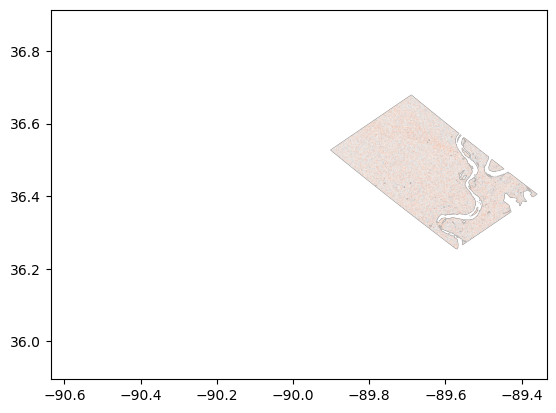

In [4]:
dSCD_fn= np.random.choice(rfolder)
dSCD_fn = '/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20250401T172306_2509111_025.npy'

print(f"{dSCD_fn=}")
gn_unmask = dSCD_fn.split('/')[-1]
rad_fn = f"{CONFIG['data_folder']}/{loc_name}/{gn_unmask[5:-4]}.nc"

dSCD = np.load(dSCD_fn)
ds_no_orth = emit_xarray(rad_fn)

wl_val = float(ds_no_orth["wavelengths"].isel(wavelengths=0))  # or a specific value
dscd_da = xr.DataArray(
    dSCD.astype('float32')[..., None],  # -> (downtrack, crosstrack, 1)
    dims=("downtrack", "crosstrack", "wavelengths"),
    coords={
        "downtrack": ds_no_orth["downtrack"],
        "crosstrack": ds_no_orth["crosstrack"],
        "wavelengths": [wl_val],
    },
    name="dSCD",
    attrs={
        "long_name": "Differential Slant Column Density (single band)",
        "units": "molec cm^-2",
    },
)

ds_no_orth = ds_no_orth.assign(dSCD=dscd_da)
ds = ortho_xr(ds_no_orth)
del ds_no_orth

bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values)  )

def imshow_quick(img):
    plt.imshow(img, cmap='RdBu_r', origin='upper',
                aspect='auto', extent=bounds)

rad1500 = ds['radiance'].sel(wavelengths=1500, method='nearest').values
dSCD_nan = np.where(rad1500 <= -8000, np.nan, ds['dSCD'].values[:,:,0])
imshow_quick(dSCD_nan)

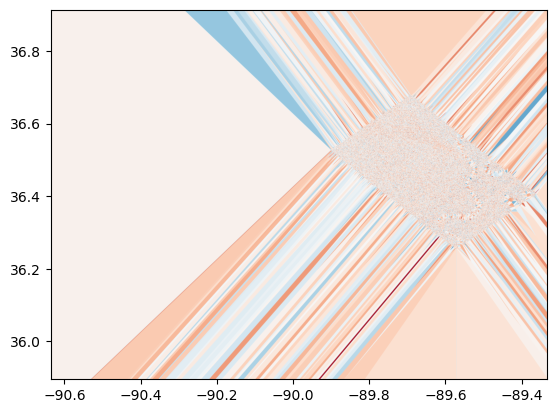

In [5]:
mask = np.isfinite(dSCD_nan)
# nearest-neighbor fill
_, idx = distance_transform_edt(~mask, return_indices=True)
filled = dSCD_nan[tuple(idx)]   # copies nearest valid value into each NaN pixel

tv = denoise_tv_chambolle(filled, weight=0.2)
tv[~mask] = np.nan

imshow_quick(filled)

Text(0.5, 1.0, 'New Madrid Crop + TV')

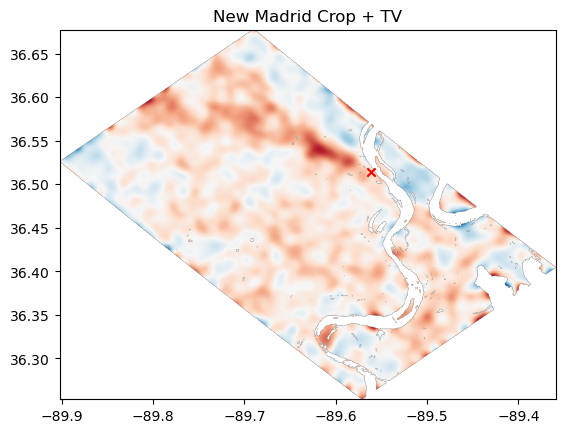

In [6]:
bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))
plt.imshow(tv, cmap='RdBu_r', origin='upper',
                aspect='auto', extent=bounds)

valid_lat = ds['latitude'].values[np.where(~np.isnan(dSCD_nan))[0]]
valid_lon = ds['longitude'].values[np.where(~np.isnan(dSCD_nan))[1]]

latmin_bnd, latmax_bnd = valid_lat.min(), valid_lat.max()
lonmin_bnd, lonmax_bnd = valid_lon.min(), valid_lon.max()

plt.xlim(lonmin_bnd, lonmax_bnd)
plt.ylim(latmin_bnd, latmax_bnd)

plt.scatter([loc_info['LON']], [loc_info['LAT']], marker='x', c='red')

plt.title("New Madrid Crop + TV")

In [30]:
dscd_fns=glob.glob(f"{CONFIG['results_folder']}/{loc_name}_CROPNOMASK1/*")

gn_unmasks = [f.split('/')[-1] for f in dscd_fns]
rad_fns = [f"{CONFIG['data_folder']}/{loc_name}/{f[5:-4]}.nc" for f in gn_unmasks]

obs_times = [datetime.strptime(d.split('_')[5], "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc) for d in gn_unmasks]
plant_lat, plant_lon = loc_info['LAT'], loc_info['LON']

geos_fp_dirs = [get_geosfp_wind(plant_lat, plant_lon, o, cache=f'{CONFIG["geosfp"]}/')['DIR50'] 
                for o in obs_times]

/orcd/home/002/kgauld/emit-nox-plumes/emit-retr/../datasets/get_geosfp.py:127: RuntimeWarning: invalid value encountered in log
  return U2_nearest * np.log((z - d) / z0) / np.log((2 - d) / z0)
/orcd/home/002/kgauld/emit-nox-plumes/emit-retr/../datasets/get_geosfp.py:127: RuntimeWarning: invalid value encountered in log
  return U2_nearest * np.log((z - d) / z0) / np.log((2 - d) / z0)
/orcd/home/002/kgauld/emit-nox-plumes/emit-retr/../datasets/get_geosfp.py:127: RuntimeWarning: invalid value encountered in log
  return U2_nearest * np.log((z - d) / z0) / np.log((2 - d) / z0)
/orcd/home/002/kgauld/emit-nox-plumes/emit-retr/../datasets/get_geosfp.py:127: RuntimeWarning: invalid value encountered in log
  return U2_nearest * np.log((z - d) / z0) / np.log((2 - d) / z0)
/orcd/home/002/kgauld/emit-nox-plumes/emit-retr/../datasets/get_geosfp.py:127: RuntimeWarning: invalid value encountered in log
  return U2_nearest * np.log((z - d) / z0) / np.log((2 - d) / z0)
/orcd/home/002/kgauld/emit-nox

In [49]:
avg_da, info = wind_aligned_stack_average([rad_fns[0]], [dscd_fns[0]], 
                                          plant_lat, plant_lon, [obs_times[0]], CONFIG,
                                         target_res_m=60.0, method="linear")

MemoryError: Unable to allocate 670. MiB for an array with shape (1984, 1242, 285) and data type bool

In [47]:
CONFIG['geosfp']='/orcd/data/dvaron/001/kgauld/GEOS_FP'

In [2]:
import EMIT_NOX

In [28]:
dSCD_fn

'/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20240205T160510_2403611_023.npy'

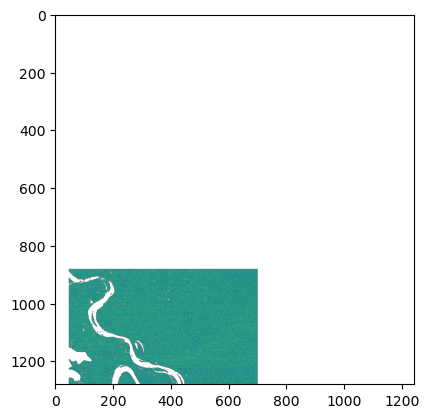

In [12]:
im=np.load('/orcd/data/dvaron/001/kgauld/EMIT/results1/New_Madrid_Power_Plant/dSCD_EMIT_L1B_RAD_001_20250401T172306_2509111_025.npy')
plt.imshow(im)

In [8]:
fn = '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20240205T160510_2403611_023.nc'
clat, clon = loc_info['LAT'], loc_info['LON']
km_boundary=30
bin_size=1

In [9]:
doas, lat, lon, mask, imask, pmask = EMIT_NOX.run_retrieval(fn, 
                                                            clat=clat, clon=clon, 
                                                            km_boundary=km_boundary, 
                                                            include_mask=True)

Starting /orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20240205T160510_2403611_023.nc...
NOX cross section created! Computing DOAS0...
Found DOAS0! Computing plume mask...
Found plume mask! Computing DOAS...
DOAS Retrieval done!


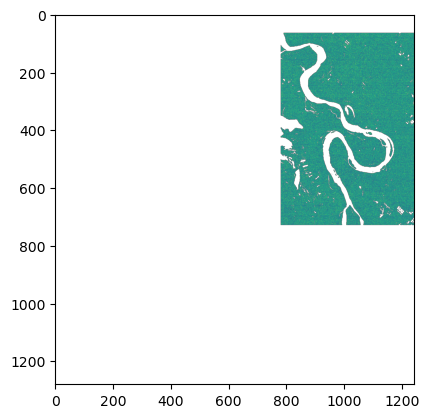

In [10]:
plt.imshow(doas)

In [34]:
ds = emit_xarray(fn)
mask = EMIT_NOX.crop_about_loc(ds, clat=clat, clon=clon, km_boundary=km_boundary)
nox_window, desired_bands = EMIT_NOX.get_NOX_cross_sec(ds)

emit_windowed = ds.sel(wavelengths=desired_bands, method='nearest')
emit_windowed = emit_windowed.coarsen(downtrack=bin_size, crosstrack=bin_size, boundary="trim").mean()

A, names = EMIT_NOX.build_design_matrix(
    emit_windowed, nox_window,
)

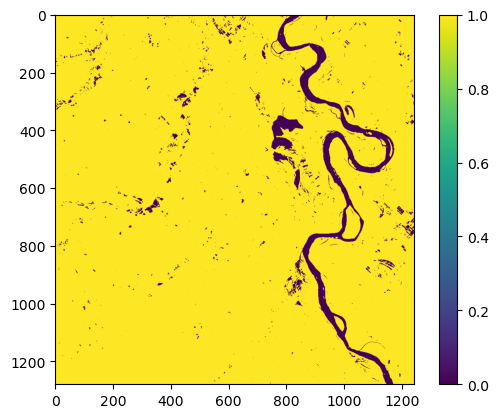

In [46]:
initial_mask = EMIT_NOX.get_envi_mask(fn)
initial_mask = 1-initial_mask.astype(np.uint8)
plt.imshow(initial_mask)
plt.colorbar()

In [44]:
DOAS0 = EMIT_NOX.run_doas_scene_vertical_striping(emit_windowed, A, names, plume_mask=initial_mask)

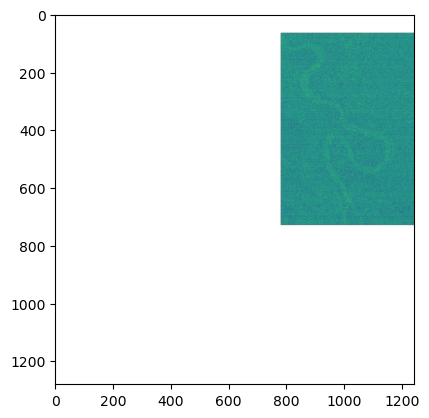

In [47]:
plt.imshow(DOAS0['dSCD'])

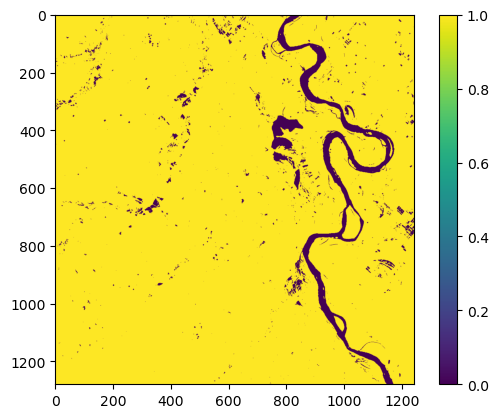

In [56]:
plume_mask = EMIT_NOX.get_plume_mask(DOAS0)
plume_mask = 1-np.clip(2-plume_mask-initial_mask, 0, 1)
plt.imshow(plume_mask)
plt.colorbar()

In [58]:
DOAS = EMIT_NOX.run_doas_scene_vertical_striping(emit_windowed, A, names, plume_mask=plume_mask)

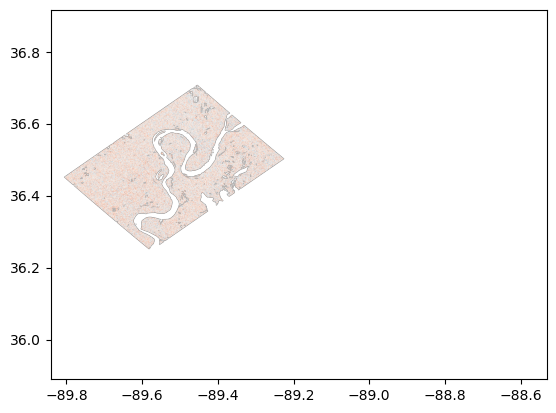

In [59]:
# dSCD = DOAS['dSCD']
dSCD = np.where(1-initial_mask, np.nan, DOAS['dSCD'])
ds_no_orth = emit_xarray(rad_fn)

wl_val = float(ds_no_orth["wavelengths"].isel(wavelengths=0))  # or a specific value
dscd_da = xr.DataArray(
    dSCD.astype('float32')[..., None],  # -> (downtrack, crosstrack, 1)
    dims=("downtrack", "crosstrack", "wavelengths"),
    coords={
        "downtrack": ds_no_orth["downtrack"],
        "crosstrack": ds_no_orth["crosstrack"],
        "wavelengths": [wl_val],
    },
    name="dSCD",
    attrs={
        "long_name": "Differential Slant Column Density (single band)",
        "units": "molec cm^-2",
    },
)

ds_no_orth = ds_no_orth.assign(dSCD=dscd_da)
ds = ortho_xr(ds_no_orth)
del ds_no_orth

bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values)  )

def imshow_quick(img):
    plt.imshow(img, cmap='RdBu_r', origin='upper',
                aspect='auto', extent=bounds)

rad1500 = ds['radiance'].sel(wavelengths=1500, method='nearest').values
dSCD_nan = np.where(rad1500 <= -8000, np.nan, ds['dSCD'].values[:,:,0])
imshow_quick(dSCD_nan)

In [60]:
mask = np.isfinite(dSCD_nan)

_, idx = distance_transform_edt(~mask, return_indices=True)
filled = dSCD_nan[tuple(idx)]   # copies nearest valid value into each NaN pixel

tv = denoise_tv_chambolle(filled, weight=0.2)
tv[~mask] = np.nan

Text(0.5, 1.0, 'New Madrid Crop + TV')

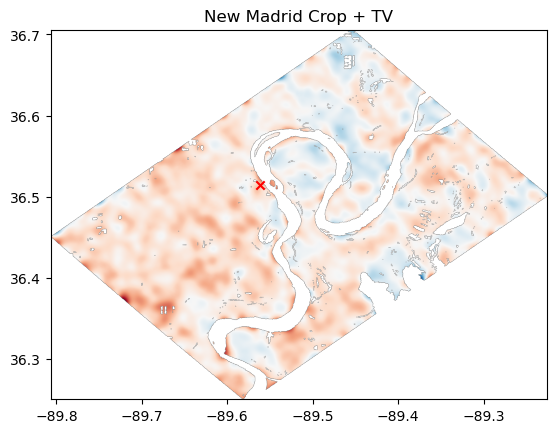

In [61]:
# mask = np.isfinite(dSCD_nan)
# filled = inpaint_biharmonic(dSCD_nan, ~mask)
# tv = denoise_tv_chambolle(filled, weight=0.2)
# tv[~mask] = np.nan

bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))
plt.imshow(tv, cmap='RdBu_r', origin='upper',
                aspect='auto', extent=bounds)

valid_lat = ds['latitude'].values[np.where(~np.isnan(dSCD_nan))[0]]
valid_lon = ds['longitude'].values[np.where(~np.isnan(dSCD_nan))[1]]

latmin_bnd, latmax_bnd = valid_lat.min(), valid_lat.max()
lonmin_bnd, lonmax_bnd = valid_lon.min(), valid_lon.max()

plt.xlim(lonmin_bnd, lonmax_bnd)
plt.ylim(latmin_bnd, latmax_bnd)

plt.scatter([loc_info['LON']], [loc_info['LAT']], marker='x', c='red')

plt.title("New Madrid Crop + TV")